TODO:
- seri çalıştırma çok uzun sürüyor a100 ile 2 l4 ile 2 çalıştırarak bölmem gerek +
- fotoğraflar çok büyük crop -> transform -> resize ? - farklı yöntemle yaptık gerek kalmadı
- parametreler tam doğru değil gibi - düzeltildi
- 10 epochtan fazla henüz çalışmadı (min 100 ort 250 epoch denemeliyim) - 500 ve 100 epoch yapıldı
- modelleri save ettikten sonra lokalde canlı videoda işlem yapılıp rapor çıkarabilmeli (eldeki drone videolarını test et) - video değil ama görüntüden rapor çıkarıldı
- modelleri ayrı ayrı test ettikten sonra birleşik test et - edildi
- SpaceNet için tüm şehirler gerekli mi? emin değilim tek tek şehirleri arttırarak gitmek daha mantıklı ama yetişmeyebilir. - tüm şehirler eklendi
- hem segmentasyon hem vit yapıyorum segmentasyon doğru olmayabiliyor onu düzeltmek gerek (parametrelerle biraz oynamak gerekli) - düzeltildi
- segmentasyon üzerinde hasar yüzdesi göster??? - rapor oluşturuldu
- vit sonuçlarını kaydet - pth kaydedildi
- FN azalt - azaltıldı

Kütüphanelerin Kurulumu

In [ ]:
#!pip install torch==1.13.1+cu118 torchvision==0.14.1+cu118 torchtext==0.14.1 torchaudio==0.13.1 torchdata==0.5.1 --extra-index-url https://download.pytorch.org/whl/cu118
!pip install -q torch torchvision torchaudio
!pip install -q transformers timm albumentations segmentation-models-pytorch opencv-python rasterio geopandas shapely matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 123.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 98.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 104.1 MB/s eta 0:00:00


Drive

In [ ]:
!apt install tree
!tree -d /content/drive/MyDrive/RemoteSensing/datasets

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tree
0 upgraded, 1 newly installed, 0 to remove and 35 not upgraded.
Need to get 47.9 kB of archives.
After this operation, 116 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tree amd64 2.0.2-1 [47.9 kB]
Fetched 47.9 kB in 0s (144 kB/s)
Selecting previously unselected package tree.
(Reading database ... 126308 files and directories currently installed.)
Preparing to unpack .../tree_2.0.2-1_amd64.deb ...
Unpacking tree (2.0.2-1) ...
Setting up tree (2.0.2-1) ...
Processing triggers for man-db (2.10.2-1) ...
/content/drive/MyDrive/RemoteSensing/datasets  [error opening dir]

0 directories


In [ ]:
#Google Drive'daki uydu görüntüsü veri seti klasör yollarını ayarlıyor ve çıktı dizinlerini oluşturuyoruz.

from google.colab import drive
import os
import torch

drive.mount('/content/drive', force_remount=True)

ROOT_DIR = '/content/drive/MyDrive/RemoteSensing/datasets'

SPACENET_DIR = os.path.join(ROOT_DIR, 'spacenet')

XBD_BASE_DIR_TRAIN = os.path.join(ROOT_DIR, 'xbd')
XBD_IMAGE_DIR = os.path.join(XBD_BASE_DIR_TRAIN, 'images')
XBD_LABEL_DIR = os.path.join(XBD_BASE_DIR_TRAIN, 'labels')

if not os.path.exists(XBD_LABEL_DIR):
    print(f"UYARI: Belirtilen xBD etiket yolu BULUNAMADI: {XBD_LABEL_DIR}")
    print("Lütfen Drive'ınızdaki 'xbd' klasörünün yapısını kontrol edin.")
    print("Eğer etiketler başka bir yoldaysa, XBD_LABEL_DIR değişkenini güncelleyin.")
else:
    print(f"xBD etiket yolu başarıyla bulundu: {XBD_LABEL_DIR}")

PREPROCESSED_SPACENET_DIR = os.path.join(ROOT_DIR, 'spacenet_preprocessed')
os.makedirs(os.path.join(PREPROCESSED_SPACENET_DIR, 'images'), exist_ok=True)
os.makedirs(os.path.join(PREPROCESSED_SPACENET_DIR, 'masks'), exist_ok=True)

OUTPUT_DIR = '/content/drive/MyDrive/RemoteSensing/project_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

MODEL_BUILDING_PATH = os.path.join(OUTPUT_DIR, 'building_segmentation_model_v3.pth')
MODEL_DAMAGE_PATH = os.path.join(OUTPUT_DIR, 'damage_classification_model_v3.pth')

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

MAX_FILES_SPACENET = None
MAX_FILES_XBD = None

Mounted at /content/drive
xBD etiket yolu başarıyla bulundu: /content/drive/MyDrive/RemoteSensing/datasets/xbd/labels
Using device: cuda


 İçe Aktarmalar ve Fonksiyonlar BU KODU BİR DAHA ÇALIŞTIRMA


SpaceNet Veri Seti Sınıfı ve DataLoader (Bina Tespiti için)

SpaceNet DataLoader created with 8524 preprocessed samples.


Maske Max Değeri: 1.0
Maskedeki Benzersiz Değerler: tensor([0., 1.])


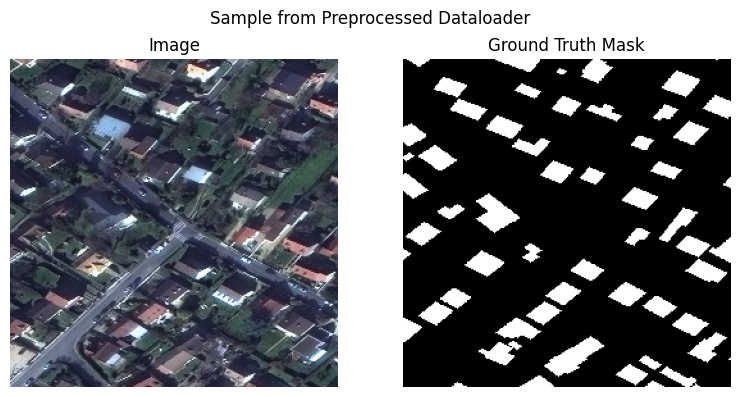

In [ ]:
# Bu hücrede SpaceNet görüntülerini ön işliyorum. Her görüntü için renk düzeltmesi yaparak 16-bit'ten 8-bit'e indiriyorum ve maskeleri düzleştirip kaydediyorum.

import cv2
from tqdm import tqdm
import rasterio
import geopandas as gpd
from rasterio.features import rasterize
from shapely.geometry import mapping
import numpy as np

print("Starting SpaceNet Pre-processing with Color Correction...")

def stretch_to_8bit(channel_data, percentile_2, percentile_98):
    denominator = percentile_98 - percentile_2
    if denominator < 1e-6:
        return np.zeros_like(channel_data, dtype=np.uint8)

    stretched = 255 * (np.clip(channel_data, percentile_2, percentile_98) - percentile_2) / denominator
    return stretched.astype(np.uint8)


all_aoi_folders = [d for d in os.listdir(SPACENET_DIR) if os.path.isdir(os.path.join(SPACENET_DIR, d))]
train_aoi_folders = [f for f in all_aoi_folders if f.startswith("AOI") and f.endswith("_Train")]

target_img_dir = os.path.join(PREPROCESSED_SPACENET_DIR, 'images')
target_mask_dir = os.path.join(PREPROCESSED_SPACENET_DIR, 'masks')

processed_count = 0

for aoi_folder in tqdm(train_aoi_folders, desc="Processing AOIs"):
    img_dir = os.path.join(SPACENET_DIR, aoi_folder, 'RGB-PanSharpen')
    geojson_dir = os.path.join(SPACENET_DIR, aoi_folder, 'geojson', 'buildings')

    if not os.path.isdir(img_dir) or not os.path.isdir(geojson_dir):
        continue

    for img_filename in os.listdir(img_dir):
        if not img_filename.endswith('.tif'):
            continue

        base_name = img_filename.replace('RGB-PanSharpen_', '').replace('.tif', '')
        geojson_filename = f"buildings_{base_name}.geojson"
        geojson_path = os.path.join(geojson_dir, geojson_filename)
        img_path = os.path.join(img_dir, img_filename)

        if os.path.exists(geojson_path):
            try:
                with rasterio.open(img_path) as src:
                    shape = (src.height, src.width)
                    transform = src.transform

                gdf = gpd.read_file(geojson_path)
                if gdf.empty:
                    continue

                geometries = [mapping(geom) for geom in gdf.geometry]
                mask = rasterize(geometries, out_shape=shape, transform=transform, fill=0, default_value=255, dtype=np.uint8)

                if np.sum(mask) == 0:
                    continue

                with rasterio.open(img_path) as src:
                    r, g, b = src.read(1).astype(np.float32), src.read(2).astype(np.float32), src.read(3).astype(np.float32)

                r_p2, r_p98 = np.percentile(r, 2), np.percentile(r, 98)
                g_p2, g_p98 = np.percentile(g, 2), np.percentile(g, 98)
                b_p2, b_p98 = np.percentile(b, 2), np.percentile(b, 98)

                r_8bit = stretch_to_8bit(r, r_p2, r_p98)
                g_8bit = stretch_to_8bit(g, g_p2, g_p98)
                b_8bit = stretch_to_8bit(b, b_p2, b_p98)

                image_bgr = cv2.merge((b_8bit, g_8bit, r_8bit))

                new_filename = f"{base_name}.png"
                cv2.imwrite(os.path.join(target_img_dir, new_filename), image_bgr)
                cv2.imwrite(os.path.join(target_mask_dir, new_filename), mask)

                processed_count += 1

            except Exception as e:
                continue

print(f"\nPre-processing complete. Saved {processed_count} image-mask pairs to {PREPROCESSED_SPACENET_DIR}")

In [ ]:
# Bu kodda hem segmentasyon (bina tespiti) hem de sınıflandırma (hasar analizi) için gerekli veri işleme fonksiyonlarını ve yapılandırmaları tanımlıyorum. Ayrıca maske üretme, bounding box çıkarma ve görselleştirme araçlarını da ekledim.

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as tv_transforms
from PIL import Image, ImageDraw
import numpy as np
import cv2
import rasterio
from rasterio.features import rasterize
import geopandas as gpd
from shapely.wkt import loads as wkt_loads
from shapely.geometry import mapping
import json
import glob
import random
from tqdm import tqdm
import matplotlib.pyplot as plt

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from transformers import ViTForImageClassification, ViTImageProcessor

IMG_SIZE_SEG = (256, 256)
IMG_SIZE_CLS = (224, 224)

XBD_DAMAGE_CLASSES = ["no-damage", "minor-damage", "major-damage", "destroyed"]
NUM_DAMAGE_CLASSES = len(XBD_DAMAGE_CLASSES)
damage_to_int = {name: i for i, name in enumerate(XBD_DAMAGE_CLASSES)}
int_to_damage = {i: name for i, name in enumerate(XBD_DAMAGE_CLASSES)}


def load_image_pil(image_path):
    return Image.open(image_path).convert("RGB")

def plot_image_mask_pred(image, mask, pred_mask=None, title=""):
    plt.figure(figsize=(12, 4) if pred_mask is not None else (8,4))
    plt.subplot(1, 3 if pred_mask is not None else 2, 1)
    plt.imshow(image)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1, 3 if pred_mask is not None else 2, 2)
    plt.imshow(mask, cmap='gray')
    plt.title("Ground Truth Mask")
    plt.axis("off")

    if pred_mask is not None:
        plt.subplot(1, 3, 3)
        plt.imshow(pred_mask, cmap='gray')
        plt.title("Predicted Mask")
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def geojson_to_mask(geojson_path, tif_path_or_shape):
    try:
        gdf = gpd.read_file(geojson_path)
        if gdf.empty:
            if isinstance(tif_path_or_shape, str):
                with rasterio.open(tif_path_or_shape) as src:
                    shape = (src.height, src.width)
            else:
                shape = tif_path_or_shape
            return np.zeros(shape, dtype=np.uint8)

        if isinstance(tif_path_or_shape, str):
            with rasterio.open(tif_path_or_shape) as src:
                transform = src.transform
                shape = (src.height, src.width)
        else:
            shape = tif_path_or_shape
            transform = rasterio.Affine.identity()

        geometries = [mapping(geom) for geom in gdf.geometry]
        mask = rasterize(geometries, out_shape=shape, transform=transform, fill=0, default_value=1, dtype=np.uint8)
        return mask
    except Exception as e:
        print(f"Error processing {geojson_path}: {e}")
        if isinstance(tif_path_or_shape, str):
            with rasterio.open(tif_path_or_shape) as src:
                shape = (src.height, src.width)
        else:
            shape = tif_path_or_shape
        return np.zeros(shape, dtype=np.uint8)


def mask_to_bounding_boxes(mask_array, min_area_threshold=50):
    contours, _ = cv2.findContours(mask_array.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    bounding_boxes = []
    for contour in contours:
        if cv2.contourArea(contour) > min_area_threshold:
            x, y, w, h = cv2.boundingRect(contour)
            bounding_boxes.append((x, y, w, h))
    return bounding_boxes

def crop_patches_from_image_pil(original_image_pil, bounding_boxes):
    patches = []
    for (x, y, w, h) in bounding_boxes:
        img_w, img_h = original_image_pil.size
        x1, y1 = max(0, x), max(0, y)
        x2, y2 = min(img_w, x + w), min(img_h, y + h)
        if x2 > x1 and y2 > y1:
            patch = original_image_pil.crop((x1, y1, x2, y2))
            patches.append(patch)
    return patches


Scanning dataset directories...


Scanning AOIs: 100%|██████████| 4/4 [00:02<00:00,  1.46it/s]


Found 10593 potential image-mask pairs.
Filtering out masks with fewer than 50 building pixels...


Filtering:   1%|          | 83/10593 [00:12<25:51,  6.77it/s]


KeyboardInterrupt: 

Found 8524 preprocessed image-mask pairs.
SpaceNet DataLoader created with 8524 samples.


/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


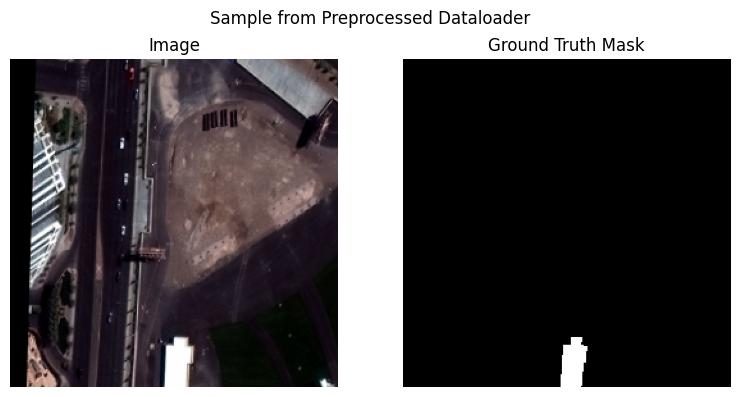

In [ ]:
# Bu hücrede, daha önce PNG formatına dönüştürdüğüm ve renk düzeltmesi yaptığım SpaceNet görüntülerini okumak için sadeleştirilmiş bir veri kümesi sınıfı tanımlıyorum. Ayrıca veri artırma (augmentation) işlemleriyle birlikte veri yükleyici (DataLoader) oluşturuyorum.
#### 1
import cv2
from albumentations.pytorch import ToTensorV2

class SpaceNetPreprocessedDataset(Dataset):
    def __init__(self, image_dir, mask_dir, max_files=None, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform

        self.image_files = sorted(os.listdir(image_dir))

        if max_files is not None and len(self.image_files) > max_files:
            self.image_files = random.sample(self.image_files, max_files)

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask / 255.0).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        mask = mask.unsqueeze(0)
        return image, mask

transform_seg = A.Compose([
    A.Resize(IMG_SIZE_SEG[0], IMG_SIZE_SEG[1]),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

preprocessed_img_dir = os.path.join(PREPROCESSED_SPACENET_DIR, 'images')
preprocessed_mask_dir = os.path.join(PREPROCESSED_SPACENET_DIR, 'masks')

try:
    spacenet_dataset = SpaceNetPreprocessedDataset(
        image_dir=preprocessed_img_dir,
        mask_dir=preprocessed_mask_dir,
        transform=transform_seg,
        max_files=MAX_FILES_SPACENET
    )

    if len(spacenet_dataset) > 0:
        spacenet_loader = DataLoader(spacenet_dataset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
        print(f"SpaceNet DataLoader created with {len(spacenet_dataset)} preprocessed samples.")

        images, masks = next(iter(spacenet_loader))
        print(f"Maske Max Değeri: {masks[0].max()}")
        print(f"Maskedeki Benzersiz Değerler: {torch.unique(masks[0])}")
        plot_image_mask_pred(images[0].permute(1,2,0).numpy() * 0.2 + 0.5, masks[0].squeeze().numpy(), title="Sample from Preprocessed Dataloader")

    else:
        print("Preprocessed dataset is empty. Please run the pre-processing cell first.")
        spacenet_loader = None
except Exception as e:
    print(f"Error creating preprocessed dataset loader: {e}")
    spacenet_loader = None

xBD Veri Seti Sınıfı ve DataLoader (Hasar Tespiti için)

SpaceNet DataLoader created with 8524 preprocessed samples.


Maske Max Değeri: 1.0
Maskedeki Benzersiz Değerler: tensor([0., 1.])


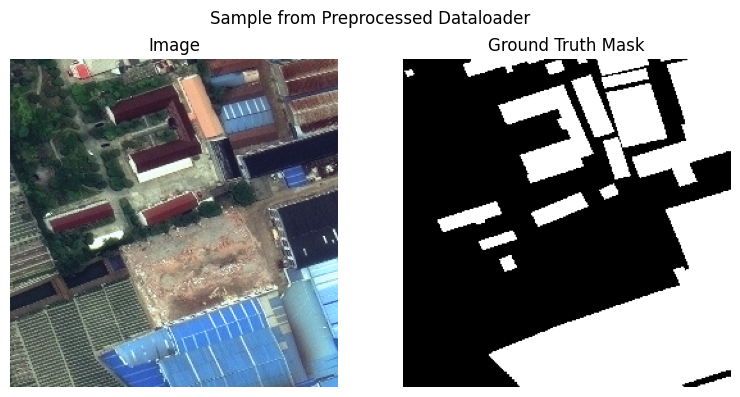

In [ ]:
# Bu hücrede, daha önce PNG formatına dönüştürdüğüm ve renk düzeltmesi yaptığım SpaceNet görüntülerini okumak için sadeleştirilmiş bir veri kümesi sınıfı tanımlıyorum. Ayrıca veri artırma (augmentation) işlemleriyle birlikte veri yükleyici (DataLoader) oluşturuyorum.
### 2
import cv2
from albumentations.pytorch import ToTensorV2

class SpaceNetPreprocessedDataset(Dataset):
    def __init__(self, image_dir, mask_dir, max_files=None, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform

        self.image_files = sorted(os.listdir(image_dir))

        if max_files is not None and len(self.image_files) > max_files:
            self.image_files = random.sample(self.image_files, max_files)

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        mask = (mask / 255.0).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        mask = mask.unsqueeze(0)
        return image, mask

transform_seg = A.Compose([
    A.Resize(IMG_SIZE_SEG[0], IMG_SIZE_SEG[1]),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

preprocessed_img_dir = os.path.join(PREPROCESSED_SPACENET_DIR, 'images')
preprocessed_mask_dir = os.path.join(PREPROCESSED_SPACENET_DIR, 'masks')

try:
    spacenet_dataset = SpaceNetPreprocessedDataset(
        image_dir=preprocessed_img_dir,
        mask_dir=preprocessed_mask_dir,
        transform=transform_seg,
        max_files=MAX_FILES_SPACENET
    )

    if len(spacenet_dataset) > 0:
        spacenet_loader = DataLoader(spacenet_dataset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
        print(f"SpaceNet DataLoader created with {len(spacenet_dataset)} preprocessed samples.")
        images, masks = next(iter(spacenet_loader))
        print(f"Maske Max Değeri: {masks[0].max()}") # 1.0 olmalı
        print(f"Maskedeki Benzersiz Değerler: {torch.unique(masks[0])}") # [0., 1.] olmalı
        plot_image_mask_pred(images[0].permute(1,2,0).numpy() * 0.2 + 0.5, masks[0].squeeze().numpy(), title="Sample from Preprocessed Dataloader")

    else:
        print("Preprocessed dataset is empty. Please run the pre-processing cell first.")
        spacenet_loader = None
except Exception as e:
    print(f"Error creating preprocessed dataset loader: {e}")
    spacenet_loader = None

In [ ]:
# Bu hücrede, xBD veri setinden bina yama görüntülerini, etiketlerini ve ilgili meta bilgileri detaylı şekilde çıkartarak kullanıma hazır hale getiriyorum. ViT uyumlu dönüştürme işlemlerini HuggingFace processor ile yapıyorum ve verileri DataLoader'a yüklüyorum. Ayrıca örnek bir görüntü ve etiketini görselleştiriyorum.

class XBDDamageDataset(Dataset):
    def __init__(self, image_dir, label_dir, damage_map, transform=None, processor=None, max_files=None, img_size=(224,224)):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.damage_map = damage_map
        self.transform = transform
        self.processor = processor
        self.img_size = img_size

        self.image_patches = []
        self.labels = []
        self.patch_bboxes_original_coords = []
        self.original_image_paths_for_patches = []

        if not os.path.exists(self.image_dir):
            print(f"ERROR: xBD Image Directory not found: {self.image_dir}")
            return

        image_files = sorted(glob.glob(os.path.join(self.image_dir, '*_post_disaster.png')))
        if not image_files:
            print(f"Warning: No '*_post_disaster.png' files found in {self.image_dir}")

        if max_files is not None and len(image_files) > max_files:
            image_files = random.sample(image_files, max_files)

        print(f"Processing {len(image_files)} xBD images (or up to max_files limit)...")
        for img_path in tqdm(image_files):
            base_name = os.path.basename(img_path).replace('_post_disaster.png', '')
            if not os.path.exists(self.label_dir):
                print(f"ERROR: xBD Label Directory not found: {self.label_dir}. Skipping {img_path}")
                continue
            json_path = os.path.join(self.label_dir, f"{base_name}_post_disaster.json")

            if not os.path.exists(json_path):
                continue

            try:
                original_pil_image = Image.open(img_path).convert("RGB")
                with open(json_path, 'r') as f:
                    label_data = json.load(f)

                for feat in label_data['features']['xy']:
                    try:
                        poly_wkt = feat['wkt']
                        damage_str = feat['properties']['subtype']

                        if damage_str not in self.damage_map:
                            continue

                        damage_label = self.damage_map[damage_str]
                        polygon = wkt_loads(poly_wkt)
                        min_x, min_y, max_x, max_y = map(int, polygon.bounds)

                        img_w_orig, img_h_orig = original_pil_image.size
                        patch_x1, patch_y1 = max(0, min_x), max(0, min_y)
                        patch_x2, patch_y2 = min(img_w_orig, max_x), min(img_h_orig, max_y)

                        if patch_x2 > patch_x1 and patch_y2 > patch_y1:
                            patch_pil = original_pil_image.crop((patch_x1, patch_y1, patch_x2, patch_y2))
                            if patch_pil.width > 0 and patch_pil.height > 0:
                                self.image_patches.append(patch_pil)
                                self.labels.append(damage_label)
                                self.patch_bboxes_original_coords.append((patch_x1, patch_y1, patch_x2 - patch_x1, patch_y2 - patch_y1))
                                self.original_image_paths_for_patches.append(img_path)

                    except Exception as e_feat:
                        pass
            except Exception as e_file:
                print(f"Error processing file {img_path} or {json_path}: {e_file}")

        print(f"Created {len(self.image_patches)} building patches from xBD dataset.")

    def __len__(self):
        return len(self.image_patches)

    def __getitem__(self, idx):
        image_patch_pil = self.image_patches[idx]
        label = self.labels[idx]

        if self.processor:
            if not isinstance(image_patch_pil, Image.Image):
                image_patch_pil = Image.fromarray(image_patch_pil)
            processed_inputs = self.processor(images=image_patch_pil, return_tensors="pt")
            image_tensor = processed_inputs.pixel_values.squeeze(0)
        elif self.transform:
            image_patch_np = np.array(image_patch_pil)
            augmented = self.transform(image=image_patch_np)
            image_tensor = augmented['image']
        else:
            temp_transform = tv_transforms.Compose([
                tv_transforms.Resize(self.img_size),
                tv_transforms.ToTensor(),
                tv_transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])
            image_tensor = temp_transform(image_patch_pil)

        return image_tensor, torch.tensor(label, dtype=torch.long)


vit_processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224-in21k')

try:
    xbd_dataset = XBDDamageDataset(
        image_dir=XBD_IMAGE_DIR,
        label_dir=XBD_LABEL_DIR,
        damage_map=damage_to_int,
        processor=vit_processor,
        max_files=MAX_FILES_XBD,
        img_size=IMG_SIZE_CLS
    )

    if len(xbd_dataset) > 0:
        xbd_loader = DataLoader(xbd_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
        print(f"xBD DataLoader created with {len(xbd_dataset)} samples.")

        images, labels = next(iter(xbd_loader))
        sample_idx = 0
        img_to_show_tensor = images[sample_idx]

        proc_mean = getattr(vit_processor, 'image_mean', [0.5, 0.5, 0.5])
        proc_std = getattr(vit_processor, 'image_std', [0.5, 0.5, 0.5])
        mean_vit = np.array(proc_mean)
        std_vit = np.array(proc_std)

        img_to_show_np = img_to_show_tensor.permute(1, 2, 0).cpu().numpy()
        img_to_show_np = std_vit * img_to_show_np + mean_vit
        img_to_show_np = np.clip(img_to_show_np, 0, 1)

        label_to_show = labels[sample_idx].item()
        plt.imshow(img_to_show_np)
        plt.title(f"Sample from xBD Dataloader\nLabel: {int_to_damage[label_to_show]} ({label_to_show})")
        plt.axis("off")
        plt.show()
    else:
        print("xBD dataset is empty. Skipping Dataloader creation and sample plot.")
        xbd_loader = None

except Exception as e:
    print(f"Error creating xBD dataset/loader: {e}")
    import traceback
    traceback.print_exc()
    xbd_loader = None

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Processing 6369 xBD images (or up to max_files limit)...


  0%|          | 24/6369 [00:14<1:05:07,  1.62it/s]


KeyboardInterrupt: 

Model Tanımlamaları

In [ ]:
# Bu fonksiyonlarda segmentasyon için U-Net ve hasar sınıflandırması için Vision Transformer (ViT) modellerini hazır hale getiriyorum. U-Net modeli bina tespiti için, ViT modeli ise her binanın hasar durumunu sınıflandırmak için kullanılıyor.

def get_building_segmentation_model(num_classes=1, encoder_name="resnet34", encoder_weights="imagenet"):
    model = smp.Unet(
        encoder_name=encoder_name,
        encoder_weights=encoder_weights,
        in_channels=3,
        classes=num_classes,
        activation='sigmoid'
    )
    return model

def get_damage_classification_model(num_damage_classes=NUM_DAMAGE_CLASSES):
    model = ViTForImageClassification.from_pretrained(
        'google/vit-base-patch16-224-in21k',
        num_labels=num_damage_classes,
        ignore_mismatched_sizes=True
    )
    return model


 Eğitim

In [ ]:
# Bu hücrede segmentasyon ve sınıflandırma modelleri için eğitim ve değerlendirme fonksiyonlarını yazdım. Eğitim fonksiyonları her epoch'ta loss ve performans ölçümlerini (IoU veya accuracy) hesaplıyor, değerlendirme fonksiyonu ise doğruluk ve tahmin listelerini döndürüyor.

def train_one_epoch_segmentation(model, dataloader, criterion, optimizer, device, epoch_num, total_epochs):
    model.train()
    running_loss = 0.0
    total_iou = 0.0

    progress_bar = tqdm(dataloader, desc=f"Seg Epoch {epoch_num+1}/{total_epochs}", leave=False)
    for images, masks in progress_bar:
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds_binary = (outputs > 0.5).float()
        intersection = torch.sum(preds_binary * masks)
        union = torch.sum(preds_binary) + torch.sum(masks) - intersection
        iou = (intersection + 1e-6) / (union + 1e-6)
        total_iou += iou.item() * images.size(0)

        progress_bar.set_postfix(loss=loss.item(), iou=iou.item())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_iou = total_iou / len(dataloader.dataset)
    return epoch_loss, epoch_iou

def train_one_epoch_classification(model, dataloader, criterion, optimizer, device, epoch_num, total_epochs):
    model.train()
    running_loss = 0.0
    correct_preds = 0
    total_samples = 0

    progress_bar = tqdm(dataloader, desc=f"Cls Epoch {epoch_num+1}/{total_epochs}", leave=False)
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(pixel_values=images).logits
        loss = criterion(outputs, labels)
        _, preds = torch.max(outputs, 1)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct_preds += torch.sum(preds == labels.data)
        total_samples += labels.size(0)

        progress_bar.set_postfix(loss=loss.item(), acc=(torch.sum(preds == labels.data).item() / labels.size(0)))

    epoch_loss = running_loss / total_samples
    epoch_acc = correct_preds.double() / total_samples
    return epoch_loss, epoch_acc.item()

def evaluate_classification_model(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct_preds = 0
    total_samples = 0

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Evaluating Model"):
            images, labels_batch = images.to(device), labels.to(device)

            outputs = model(pixel_values=images).logits
            loss = criterion(outputs, labels_batch)
            _, preds_batch = torch.max(outputs, 1)

            running_loss += loss.item() * images.size(0)
            correct_preds += torch.sum(preds_batch == labels_batch.data)
            total_samples += labels_batch.size(0)

            all_labels.extend(labels_batch.cpu().numpy())
            all_preds.extend(preds_batch.cpu().numpy())

    val_loss = running_loss / total_samples
    val_acc = correct_preds.double() / total_samples

    return val_loss, val_acc.item(), all_labels, all_preds


Bina Segmentasyon Modeli Eğitim

In [ ]:
# Bu hücrede, SpaceNet veri seti üzerinde bina segmentasyonu yapmak üzere U-Net tabanlı bir model eğitiyorum. Kayıp fonksiyonu olarak Focal Loss ve Dice Loss kombinasyonu kullanıyorum, en iyi modeli IoU skoruna göre kaydediyorum.

import segmentation_models_pytorch as smp
import segmentation_models_pytorch.losses as smp_losses
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm

if spacenet_loader:
    print("\n--- Training Building Segmentation Model (with Preprocessed Data) ---")

    building_seg_model = smp.Unet(
        encoder_name="resnet50",
        encoder_weights="imagenet",
        in_channels=3,
        classes=1,
        activation='sigmoid'
    ).to(DEVICE)

    class CombinedLoss(nn.Module):
        def __init__(self, alpha=0.8, beta=0.2):
            super().__init__()
            self.alpha = alpha
            self.beta = beta
            self.focal = smp_losses.FocalLoss(mode='binary')
            self.dice = smp_losses.DiceLoss(mode='binary')
        def forward(self, pred, target):
            return self.alpha * self.focal(pred, target) + self.beta * self.dice(pred, target)

    criterion_seg = CombinedLoss(alpha=0.8, beta=0.2).to(DEVICE)

    optimizer_seg = optim.AdamW(building_seg_model.parameters(), lr=1e-4, weight_decay=1e-5)
    scheduler_seg = optim.lr_scheduler.ReduceLROnPlateau(optimizer_seg, mode='max', patience=3, factor=0.5, verbose=True)

    num_epochs_seg = 500
    best_seg_iou = -1.0

    print(f"Starting segmentation training for {num_epochs_seg} epochs...")
    for epoch in range(num_epochs_seg):
        epoch_loss, epoch_iou = train_one_epoch_segmentation(
            building_seg_model, spacenet_loader, criterion_seg, optimizer_seg, DEVICE, epoch, num_epochs_seg
        )

        scheduler_seg.step(epoch_iou)

        print(f"Seg. Epoch {epoch+1}/{num_epochs_seg} -> Loss: {epoch_loss:.4f}, IoU: {epoch_iou:.4f}, LR: {optimizer_seg.param_groups[0]['lr']:.1e}")

        if epoch_iou > best_seg_iou:
            best_seg_iou = epoch_iou
            torch.save(building_seg_model.state_dict(), MODEL_BUILDING_PATH)
            print(f"Saved new best segmentation model with IoU: {best_seg_iou:.4f} at epoch {epoch+1}")

    print(f"\nBuilding segmentation model training finished. Best IoU achieved: {best_seg_iou:.4f}")
else:
    print("SpaceNet DataLoader not available. Skipping segmentation model training.")
    building_seg_model = None


--- Training Building Segmentation Model (with Preprocessed Data) ---
Starting segmentation training for 500 epochs...


Seg. Epoch 1/500 -> Loss: 0.3141, IoU: 0.4707, LR: 1.0e-04
Saved new best segmentation model with IoU: 0.4707 at epoch 1


Seg. Epoch 2/500 -> Loss: 0.2782, IoU: 0.5442, LR: 1.0e-04
Saved new best segmentation model with IoU: 0.5442 at epoch 2


Seg. Epoch 3/500 -> Loss: 0.2732, IoU: 0.5658, LR: 1.0e-04
Saved new best segmentation model with IoU: 0.5658 at epoch 3


Seg. Epoch 4/500 -> Loss: 0.2712, IoU: 0.5859, LR: 1.0e-04
Saved new best segmentation model with IoU: 0.5859 at epoch 4


...

Seg. Epoch 496/500 -> Loss: 0.2617, IoU: 0.7651, LR: 1.2e-08


Seg. Epoch 497/500 -> Loss: 0.2616, IoU: 0.7648, LR: 1.2e-08


Seg. Epoch 498/500 -> Loss: 0.2617, IoU: 0.7654, LR: 1.2e-08


Seg. Epoch 499/500 -> Loss: 0.2617, IoU: 0.7649, LR: 1.2e-08


Seg. Epoch 500/500 -> Loss: 0.2616, IoU: 0.7652, LR: 1.2e-08

Building segmentation model training finished. Best IoU achieved: 0.7664


In [ ]:
#save
torch.save(building_seg_model.state_dict(), "building_segmentation_model_v3_final_not_best.pth")

 Hasar Sınıflandırma Modeli Eğitim

In [ ]:
# Bu hücrede Vision Transformer tabanlı hasar sınıflandırma modelinin eğitimini başlatıyorum. Eğitim sırasında doğrulama setiyle performansı izliyorum, en iyi doğruluk elde edildiğinde modeli kaydediyorum ve erken durdurma uyguluyorum.

if xbd_train_loader and xbd_val_loader:
    print("\n--- Hasar Tespiti Modeli Eğitimi (Doğrulama ile) ---")
    damage_cls_model = get_damage_classification_model(num_damage_classes=NUM_DAMAGE_CLASSES).to(DEVICE)

    criterion_cls = nn.CrossEntropyLoss()
    optimizer_cls = optim.AdamW(damage_cls_model.parameters(), lr=5e-5, weight_decay=1e-5)
    scheduler_cls = optim.lr_scheduler.ReduceLROnPlateau(optimizer_cls, mode='max', patience=5, factor=0.2, verbose=True)

    num_epochs_cls = 100
    best_val_acc = 0.0
    patience_counter = 0
    early_stopping_patience = 10

    print(f"Sınıflandırma eğitimi {num_epochs_cls} epoch'a kadar başlatılıyor...")
    for epoch in range(num_epochs_cls):
        train_loss, train_acc = train_one_epoch_classification(
            damage_cls_model, xbd_train_loader, criterion_cls, optimizer_cls, DEVICE, epoch, num_epochs_cls
        )

        val_loss, val_acc, _, _ = evaluate_classification_model(
            damage_cls_model, xbd_val_loader, criterion_cls, DEVICE
        )

        scheduler_cls.step(val_acc)

        print(f"Epoch {epoch+1}/{num_epochs_cls} -> Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(damage_cls_model.state_dict(), MODEL_DAMAGE_PATH)
            print(f"Yeni en iyi model kaydedildi. Doğrulama Başarımı: {best_val_acc:.4f} (Epoch {epoch+1})")
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= early_stopping_patience:
            print(f"Doğrulama başarımı {early_stopping_patience} epoch'tur artmadı. Eğitim erken durduruluyor.")
            break

    print(f"Sınıflandırma eğitimi tamamlandı. En iyi doğrulama başarımı: {best_val_acc:.4f}")
else:
    print("xBD DataLoader oluşturulamadı. Hasar tespiti eğitimi atlanıyor.")


NameError: name 'xbd_loader' is not defined

Inference

In [ ]:
# Bu fonksiyonda, hem bina segmentasyon hem de hasar sınıflandırma modellerini kullanarak tek bir görüntü üzerinde uçtan uca tahmin sürecini çalıştırıyorum. Tespit edilen binaları kırpıyor, her biri için hasar seviyesini tahmin ediyor ve sonuçları görselleştirip özet bir rapor üretiyorum.

def run_inference_pipeline(image_path_or_pil, building_model, damage_model,
                           seg_transform, cls_processor, device,
                           seg_img_size=IMG_SIZE_SEG, cls_img_size=IMG_SIZE_CLS,
                           min_building_area_px=100):

    if building_model is None or damage_model is None:
        print("Error: One or both models are not loaded/trained.")
        return None, None

    building_model.eval().to(device)
    damage_model.eval().to(device)

    if isinstance(image_path_or_pil, str):
        try:
            original_pil_image = Image.open(image_path_or_pil).convert("RGB")
        except FileNotFoundError:
            print(f"Error: Test image not found at {image_path_or_pil}")
            return None, None
    elif isinstance(image_path_or_pil, Image.Image):
        original_pil_image = image_path_or_pil.convert("RGB")
    else:
        print("Error: Invalid image input. Must be a path or PIL Image.")
        return None, None

    original_cv_image = cv2.cvtColor(np.array(original_pil_image), cv2.COLOR_RGB2BGR)
    original_w, original_h = original_pil_image.size

    print("Step 1: Detecting buildings...")
    img_np_for_seg = np.array(original_pil_image)
    augmented_seg = seg_transform(image=img_np_for_seg)
    input_tensor_seg = augmented_seg['image'].unsqueeze(0).to(device)

    with torch.no_grad():
        output_mask_tensor_seg = building_model(input_tensor_seg)

    predicted_mask_resized_seg = (output_mask_tensor_seg.squeeze().cpu().numpy() > 0.5).astype(np.uint8)
    predicted_mask_original_size = cv2.resize(predicted_mask_resized_seg, (original_w, original_h), interpolation=cv2.INTER_NEAREST)

    print("Step 2: Extracting building patches...")
    building_bboxes = mask_to_bounding_boxes(predicted_mask_original_size, min_area_threshold=min_building_area_px)

    if not building_bboxes:
        print("No buildings detected (or all were below min_area_threshold).")
        cv2.putText(original_cv_image, "No buildings detected", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,255), 2, cv2.LINE_AA)
        return original_cv_image, {"total_buildings": 0, "damage_counts_by_class_str": {name:0 for name in XBD_DAMAGE_CLASSES}, "percentage_heavily_damaged": 0}

    num_total_buildings = len(building_bboxes)
    print(f"Found {num_total_buildings} potential buildings.")

    building_patches_pil = crop_patches_from_image_pil(original_pil_image, building_bboxes)
    if not building_patches_pil:
        print("No valid patches could be cropped (e.g., all bboxes were empty after clipping).")
        cv2.putText(original_cv_image, "No valid building patches", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,255), 2, cv2.LINE_AA)
        return original_cv_image, {"total_buildings": num_total_buildings, "damage_counts_by_class_str": {name:0 for name in XBD_DAMAGE_CLASSES}, "percentage_heavily_damaged": 0}

    print(f"Step 3: Assessing damage for {len(building_patches_pil)} building patches...")
    damage_predictions = []

    for i, patch_pil in enumerate(tqdm(building_patches_pil, desc="Classifying patches")):
        if patch_pil.width == 0 or patch_pil.height == 0: continue
        if patch_pil.mode != "RGB": patch_pil = patch_pil.convert("RGB")

        processed_inputs = cls_processor(images=patch_pil, return_tensors="pt")
        pixel_values = processed_inputs.pixel_values.to(device)

        with torch.no_grad():
            logits = damage_model(pixel_values=pixel_values).logits
            predicted_class_idx = logits.argmax(-1).item()

        damage_str = int_to_damage.get(predicted_class_idx, "Unknown")
        damage_predictions.append({
            "bbox": building_bboxes[i],
            "damage_int": predicted_class_idx,
            "damage_str": damage_str
        })

    print("\n--- Damage Assessment Report ---")
    damage_counts_int = {i: 0 for i in int_to_damage.keys()}
    for pred in damage_predictions:
        damage_counts_int[pred['damage_int']] = damage_counts_int.get(pred['damage_int'], 0) + 1

    damage_counts_str = {int_to_damage[k]: v for k, v in damage_counts_int.items()}

    print(f"Total buildings passed to damage classifier: {len(damage_predictions)}")
    print(f"Initial building detections (before patch cropping quality check): {num_total_buildings}")

    for dmg_str, count in damage_counts_str.items():
        print(f"  {dmg_str}: {count} buildings")

    num_heavily_damaged = damage_counts_str.get("major-damage", 0) + damage_counts_str.get("destroyed", 0)
    denominator_for_percentage = len(damage_predictions) if len(damage_predictions) > 0 else 1
    percentage_heavily_damaged = (num_heavily_damaged / denominator_for_percentage) * 100
    print(f"\nPercentage of heavily damaged or destroyed buildings (among classified patches): {percentage_heavily_damaged:.2f}%")

    output_viz_image = original_cv_image.copy()
    for pred in damage_predictions:
        x, y, w, h = pred['bbox']
        damage_cls_str = pred['damage_str']

        color = (0, 255, 0)
        if damage_cls_str == "minor-damage": color = (0, 255, 255)
        elif damage_cls_str == "major-damage": color = (0, 165, 255)
        elif damage_cls_str == "destroyed": color = (0, 0, 255)

        cv2.rectangle(output_viz_image, (x, y), (x+w, y+h), color, 2)
        cv2.putText(output_viz_image, damage_cls_str[:7], (x, y-5 if y-5 > 5 else y+10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1, cv2.LINE_AA)

    summary_text = f"Classified: {len(damage_predictions)}, HeavyDmg: {num_heavily_damaged} ({percentage_heavily_damaged:.1f}%)"
    cv2.putText(output_viz_image, summary_text, (10, original_h - 10 if original_h -10 > 40 else 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2, cv2.LINE_AA)

    report_data = {
        "initial_detections": num_total_buildings,
        "classified_patches": len(damage_predictions),
        "damage_counts_by_class_str": damage_counts_str,
        "num_heavily_damaged": num_heavily_damaged,
        "percentage_heavily_damaged_of_classified": percentage_heavily_damaged
    }

    return output_viz_image, report_data


Inference Çalıştırma

In [ ]:
print("\n--- Running Full Inference Pipeline ---")

# 1. Eğitilmiş Modelleri Yükle
loaded_building_model = None
if os.path.exists(MODEL_BUILDING_PATH):
    # Modelin kaydedildiği encoder_name ile yüklenmesi önemli.
    # Eğer eğitimde encoder_name değiştiyse, burada da değiştirin.
    loaded_building_model = get_building_segmentation_model(encoder_name="resnet50") # Eğitimdekiyle aynı olmalı
    loaded_building_model.load_state_dict(torch.load(MODEL_BUILDING_PATH, map_location=DEVICE))
    loaded_building_model.to(DEVICE)
    loaded_building_model.eval()
    print(f"Loaded trained building segmentation model from {MODEL_BUILDING_PATH}")
else:
    print(f"Building segmentation model not found at {MODEL_BUILDING_PATH}.")
    if 'building_seg_model' in globals() and building_seg_model is not None:
        print("Using recently trained building_seg_model for inference.")
        loaded_building_model = building_seg_model.eval() # Make sure it's in eval mode
    else:
        print("No trained building model available. Inference will likely fail or produce random results.")


loaded_damage_model = None
if os.path.exists(MODEL_DAMAGE_PATH):
    loaded_damage_model = get_damage_classification_model(num_damage_classes=NUM_DAMAGE_CLASSES)
    loaded_damage_model.load_state_dict(torch.load(MODEL_DAMAGE_PATH, map_location=DEVICE))
    loaded_damage_model.to(DEVICE)
    loaded_damage_model.eval()
    print(f"Loaded trained damage classification model from {MODEL_DAMAGE_PATH}")
else:
    print(f"Damage classification model not found at {MODEL_DAMAGE_PATH}.")
    if 'damage_cls_model' in globals() and damage_cls_model is not None:
        print("Using recently trained damage_cls_model for inference.")
        loaded_damage_model = damage_cls_model.eval() # Make sure it's in eval mode
    else:
        print("No trained damage model available. Inference will likely fail or produce random results.")


# 2. Test Görüntüsü Seç
test_image_path = None
if XBD_IMAGE_DIR and os.path.exists(XBD_IMAGE_DIR):
    potential_test_images = glob.glob(os.path.join(XBD_IMAGE_DIR, '*_post_disaster.png'))
    if potential_test_images:
        test_image_path = random.choice(potential_test_images)
        print(f"Using random xBD image for testing: {test_image_path}")
    else:
        print(f"No '*_post_disaster.png' images found in {XBD_IMAGE_DIR} for testing.")
else:
    print(f"XBD_IMAGE_DIR ({XBD_IMAGE_DIR}) not valid or does not exist for test image selection.")

# Kendi test görüntünüzü kullanmak için:
# test_image_path = "/content/drive/MyDrive/RemoteSensing/my_test_images/drone_frame_001.png"
# if not os.path.exists(test_image_path):
#    print(f"Custom test image path not found: {test_image_path}")
#    test_image_path = None # Fallback

if test_image_path is None:
    print("No test image specified or found. Creating a dummy image for inference pipeline structure test.")
    dummy_img = Image.new('RGB', (768, 768), color = 'darkgray') # Daha büyük dummy
    draw = ImageDraw.Draw(dummy_img)
    # Üzerine birkaç "bina" çizelim
    for i in range(5): # Daha fazla dummy bina
        x0, y0 = random.randint(50, 600), random.randint(50, 600)
        w, h = random.randint(50,150), random.randint(50,150)
        col = random.choice([(100,100,200), (120,120,220), (150,150,250), (90,90,180)])
        draw.rectangle((x0,y0,x0+w,y0+h), fill=col)
    test_image_input = dummy_img
    test_image_filename = "dummy_test_output_final.png"
else:
    test_image_input = test_image_path
    test_image_filename = os.path.basename(test_image_path).replace(".png", "_damage_assessment_final.png")


# 3. Pipeline'ı Çalıştır
if loaded_building_model and loaded_damage_model and test_image_input:
    inference_seg_transform = A.Compose([
        A.Resize(IMG_SIZE_SEG[0], IMG_SIZE_SEG[1]),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ])
    inference_cls_processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224-in21k')

    print(f"Running inference on: {test_image_filename}")
    visual_output_image, report = run_inference_pipeline(
        test_image_input,
        loaded_building_model,
        loaded_damage_model,
        inference_seg_transform,
        inference_cls_processor,
        DEVICE,
        seg_img_size=IMG_SIZE_SEG,
        cls_img_size=IMG_SIZE_CLS,
        min_building_area_px=1 # Bu eşiği deneyerek ayarlayın. Küçük binalar için düşürün.
    )

    if visual_output_image is not None:
        output_image_path = os.path.join(OUTPUT_DIR, test_image_filename)
        cv2.imwrite(output_image_path, visual_output_image)
        print(f"\nDamage assessment visualization saved to: {output_image_path}")

        plt.figure(figsize=(15,15)) # Daha büyük gösterim
        plt.imshow(cv2.cvtColor(visual_output_image, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title(f"Damage Assessment: {os.path.basename(test_image_filename)}", fontsize=16)
        plt.show()

        print("\n--- Final Report ---")
        if report:
            for key, value in report.items():
                if isinstance(value, dict):
                    print(f"  {key}:")
                    for k_inner, v_inner in value.items():
                        print(f"    {k_inner}: {v_inner}")
                else:
                    print(f"  {key}: {value}")
            # Raporu JSON olarak da kaydedebilirsiniz
            report_json_path = os.path.join(OUTPUT_DIR, test_image_filename.replace('.png', '_report.json'))
            with open(report_json_path, 'w') as f:
                json.dump(report, f, indent=2)
            print(f"Report saved to: {report_json_path}")

    else:
        print("Inference pipeline did not produce a visual output or report.")
else:
    print("Models not properly loaded or no test image available. Skipping inference.")

In [ ]:
# Bu hücrede eğitilmiş bina segmentasyon ve hasar sınıflandırma modellerini yüklüyorum, test için rastgele bir xBD görüntüsü (veya dummy görüntü) seçiyorum ve inference pipeline’ı çalıştırarak görsel çıktı ve istatistiksel rapor üretiyorum.

print("\n--- Running Full Inference Pipeline ---")

loaded_building_model = None
if os.path.exists(MODEL_BUILDING_PATH):
    loaded_building_model = get_building_segmentation_model(encoder_name="resnet50")
    loaded_building_model.load_state_dict(torch.load(MODEL_BUILDING_PATH, map_location=DEVICE))
    loaded_building_model.to(DEVICE)
    loaded_building_model.eval()
    print(f"Loaded trained building segmentation model from {MODEL_BUILDING_PATH}")
else:
    print(f"Building segmentation model not found at {MODEL_BUILDING_PATH}.")
    if 'building_seg_model' in globals() and building_seg_model is not None:
        print("Using recently trained building_seg_model for inference.")
        loaded_building_model = building_seg_model.eval()
    else:
        print("No trained building model available. Inference will likely fail or produce random results.")

loaded_damage_model = None
if os.path.exists(MODEL_DAMAGE_PATH):
    loaded_damage_model = get_damage_classification_model(num_damage_classes=NUM_DAMAGE_CLASSES)
    loaded_damage_model.load_state_dict(torch.load(MODEL_DAMAGE_PATH, map_location=DEVICE))
    loaded_damage_model.to(DEVICE)
    loaded_damage_model.eval()
    print(f"Loaded trained damage classification model from {MODEL_DAMAGE_PATH}")
else:
    print(f"Damage classification model not found at {MODEL_DAMAGE_PATH}.")
    if 'damage_cls_model' in globals() and damage_cls_model is not None:
        print("Using recently trained damage_cls_model for inference.")
        loaded_damage_model = damage_cls_model.eval()
    else:
        print("No trained damage model available. Inference will likely fail or produce random results.")

test_image_path = None
if XBD_IMAGE_DIR and os.path.exists(XBD_IMAGE_DIR):
    potential_test_images = glob.glob(os.path.join(XBD_IMAGE_DIR, '*_post_disaster.png'))
    if potential_test_images:
        test_image_path = random.choice(potential_test_images)
        print(f"Using random xBD image for testing: {test_image_path}")
    else:
        print(f"No '*_post_disaster.png' images found in {XBD_IMAGE_DIR} for testing.")
else:
    print(f"XBD_IMAGE_DIR ({XBD_IMAGE_DIR}) not valid or does not exist for test image selection.")

if test_image_path is None:
    print("No test image specified or found. Creating a dummy image for inference pipeline structure test.")
    dummy_img = Image.new('RGB', (768, 768), color = 'darkgray')
    draw = ImageDraw.Draw(dummy_img)
    for i in range(5):
        x0, y0 = random.randint(50, 600), random.randint(50, 600)
        w, h = random.randint(50,150), random.randint(50,150)
        col = random.choice([(100,100,200), (120,120,220), (150,150,250), (90,90,180)])
        draw.rectangle((x0,y0,x0+w,y0+h), fill=col)
    test_image_input = dummy_img
    test_image_filename = "dummy_test_output_final.png"
else:
    test_image_input = test_image_path
    test_image_filename = os.path.basename(test_image_path).replace(".png", "_damage_assessment_final.png")

if loaded_building_model and loaded_damage_model and test_image_input:
    inference_seg_transform = A.Compose([
        A.Resize(IMG_SIZE_SEG[0], IMG_SIZE_SEG[1]),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ])
    inference_cls_processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224-in21k')

    print(f"Running inference on: {test_image_filename}")
    visual_output_image, report = run_inference_pipeline(
        test_image_input,
        loaded_building_model,
        loaded_damage_model,
        inference_seg_transform,
        inference_cls_processor,
        DEVICE,
        seg_img_size=IMG_SIZE_SEG,
        cls_img_size=IMG_SIZE_CLS,
        min_building_area_px=1
    )

    if visual_output_image is not None:
        output_image_path = os.path.join(OUTPUT_DIR, test_image_filename)
        cv2.imwrite(output_image_path, visual_output_image)
        print(f"\nDamage assessment visualization saved to: {output_image_path}")

        plt.figure(figsize=(15,15))
        plt.imshow(cv2.cvtColor(visual_output_image, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title(f"Damage Assessment: {os.path.basename(test_image_filename)}", fontsize=16)
        plt.show()

        print("\n--- Final Report ---")
        if report:
            for key, value in report.items():
                if isinstance(value, dict):
                    print(f"  {key}:")
                    for k_inner, v_inner in value.items():
                        print(f"    {k_inner}: {v_inner}")
                else:
                    print(f"  {key}: {value}")
            report_json_path = os.path.join(OUTPUT_DIR, test_image_filename.replace('.png', '_report.json'))
            with open(report_json_path, 'w') as f:
                json.dump(report, f, indent=2)
            print(f"Report saved to: {report_json_path}")
    else:
        print("Inference pipeline did not produce a visual output or report.")
else:
    print("Models not properly loaded or no test image available. Skipping inference.")